# Anomaly Detection in IoT Data — Autoencoder Training

A convolutional autoencoder learns to reconstruct normal sensor windows. A high reconstruction error later becomes an anomaly signal.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

NORMAL_URL = "https://raw.githubusercontent.com/numenta/NAB/master/data/artificialNoAnomaly/art_daily_small_noise.csv"
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)
TIME_STEPS = 60
BATCH_SIZE = 64
EPOCHS = 25
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
normal = pd.read_csv(NORMAL_URL, parse_dates=["timestamp"])
values = normal["value"].astype("float32").to_numpy()
mean = float(values.mean())
std = float(values.std())
scaled = (values - mean) / std

def create_sequences(values, time_steps=TIME_STEPS):
    return np.stack([values[i:i + time_steps] for i in range(len(values) - time_steps + 1)])

x = create_sequences(scaled)
x = x[..., np.newaxis]

split = int(len(x) * 0.8)
x_train, x_val = x[:split], x[split:]
print("Training shape:", x_train.shape)
print("Validation shape:", x_val.shape)

Training shape: (3178, 60, 1)
Validation shape: (795, 60, 1)


## Build the convolutional autoencoder

In [3]:
model = keras.Sequential([
    layers.Input(shape=(TIME_STEPS, 1)),
    layers.Conv1D(32, 7, padding="same", activation="relu"),
    layers.MaxPooling1D(2, padding="same"),
    layers.Conv1D(16, 7, padding="same", activation="relu"),
    layers.MaxPooling1D(2, padding="same"),
    layers.Conv1D(16, 7, padding="same", activation="relu"),
    layers.UpSampling1D(2),
    layers.Conv1D(32, 7, padding="same", activation="relu"),
    layers.UpSampling1D(2),
    layers.Conv1D(1, 7, padding="same")
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="mae")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 32)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 16)         │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 16)         │         1,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 60, 1)          │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
history = model.fit(
    x_train, x_train,
    validation_data=(x_val, x_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.3229 - val_loss: 0.1547
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1217 - val_loss: 0.1039
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0946 - val_loss: 0.0921
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0865 - val_loss: 0.0861
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0825 - val_loss: 0.0829
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0803 - val_loss: 0.0810
Epoch 7/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0781 - val_loss: 0.0792
Epoch 8/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0767 - val_loss: 0.0780
Epoch 9/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0759 - val_loss: 0.0775
Epoch 10/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0750 - val_loss: 0.0774
Epoch 11/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0741 - val_loss: 0.0767
Epoch 12/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0

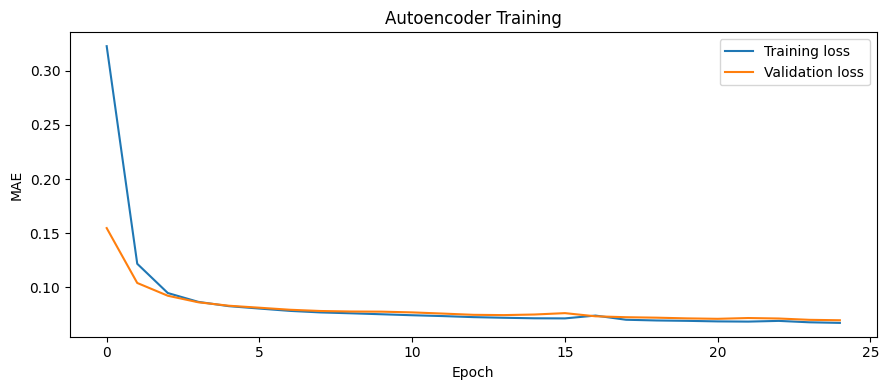

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history.history["loss"], label="Training loss")
ax.plot(history.history["val_loss"], label="Validation loss")
ax.set_title("Autoencoder Training")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()

## Choose an anomaly threshold

We calculate reconstruction error on normal validation windows. The 99th percentile is used as a practical threshold, leaving a small margin for normal variation.

Anomaly threshold: 0.128943


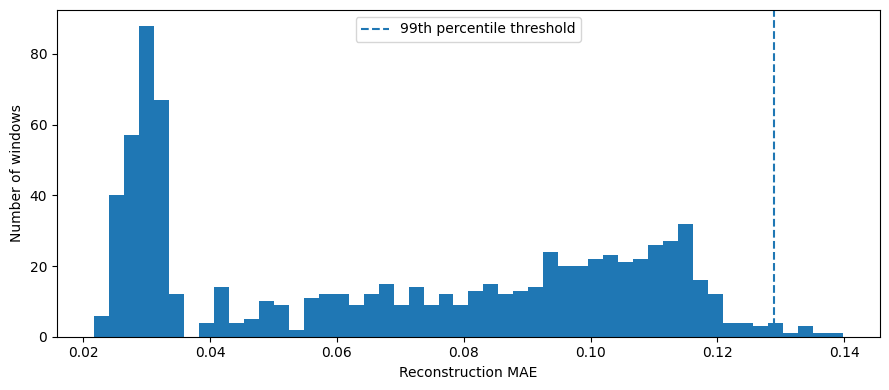

In [6]:
val_pred = model.predict(x_val, verbose=0)
errors = np.mean(np.abs(val_pred - x_val), axis=(1, 2))
threshold = float(np.percentile(errors, 99))
print(f"Anomaly threshold: {threshold:.6f}")

plt.figure(figsize=(9, 4))
plt.hist(errors, bins=50)
plt.axvline(threshold, linestyle="--", label="99th percentile threshold")
plt.xlabel("Reconstruction MAE")
plt.ylabel("Number of windows")
plt.legend()
plt.tight_layout()
plt.show()

## Save artifacts for the Flask application

In [7]:
model.save(MODEL_DIR / "iot_autoencoder.keras")
with open(MODEL_DIR / "scaler.json", "w", encoding="utf-8") as f:
    json.dump({"mean": mean, "std": std, "time_steps": TIME_STEPS}, f, indent=2)
with open(MODEL_DIR / "threshold.json", "w", encoding="utf-8") as f:
    json.dump({"threshold": threshold}, f, indent=2)

print("Saved model and configuration files to ../models/")

Saved model and configuration files to ../models/
